# KOSIS_API_v8 - KOSIS 통계 수집 → investar 적재

KOSIS(국가통계포털) 통계표를 받아 investar에 저장합니다. 소매판매액지수로 시작하고, 다른 KOSIS 통계표도 **등록표에 한 줄 추가**하면 같은 테이블에 쌓입니다.

**저장 테이블 (investar, 표준 규격 STD-1)**

| 테이블 | 내용 | 키 |
|---|---|---|
| `kr_kosis_series_info` | 시리즈 설명표 (통계표, 항목, 분류 C1~C8, 단위, 통계표 갱신일) | series_id |
| `kr_kosis_data` | 값 최신본 (시리즈 x 기간 1행) | series_id, period_end |
| `kr_kosis_data_vintage` | 값이 처음 들어오거나 바뀐 이력 | id |

- `series_id` = `kosis_` + (기관·통계표·항목·분류코드) 해시 16자리. 같은 항목·분류는 항상 같은 series_id
- STD-1: 소문자 snake_case / utf8mb4_general_ci / `period_end`(기간 말일) + `freq` / 수집 시각 KST / 이력 `_vintage` / 단위는 설명표

**v8**: KOSIS 최종수정일(LST_CHN_DE)이 `2026-09-30`처럼 하이픈 형식으로 와서 DB 날짜 오류(1292)가 나던 문제 수정. 오류 메시지를 짧게 표시

**v7**: 진행 표시(tqdm)와 소요시간 측정 추가. 요청 크기를 통계표 크기에 맞춰 자동 조절(요청 수 감소), 연결 재사용, 느린 요청 재시도.
6-1번 셀에서 어디서 시간이 걸렸는지(API / DB) 확인 가능

**v6**: 소매판매 관련 통계표 4개 추가 (온라인쇼핑 3종, 소매업태별 판매액). 같은 kr_kosis_* 테이블에 저장

**v5**: 9번 셀 추가 - 수집된 KOSIS 데이터를 DataFrame(긴 표, 넓은 표)으로 보기

**v4**: KEYS.py 를 다른 코드와 같은 방식(`from DATA.KEYS import KEYS`)으로 먼저 불러오고, 실패 시 경로로 불러옴. 키를 못 찾으면 KEYS.py 구성을 진단해 보여줌

**v1에서 바뀐 점**
- v1 첫 셀의 `statisticsData.do`는 '사용자 등록 통계'용 주소라 `필수요청변수 누락(20)` 오류가 났습니다 → 통계표 직접 조회 주소(`Param/statisticsParameterData.do`)로 통일
- 분류 단계(objL1~objL8)와 주기(M/Q/Y)를 자동으로 찾음. 4만 셀 제한에 걸리면 기간을 자동으로 쪼개 받음
- API 키를 코드에서 빼고 `DATA/KEYS.py`에서 읽음. 오류 메시지의 키는 `***`로 가림
- 처음엔 전체 기간, 이후엔 DB 마지막 시점 기준 최근 몇 기간만 갱신

**사용 순서**: 1~4번 셀 → 5번 통계표 확인(이름이 맞는지 보기) → 6번 수집·적재 → 7번 검증 → 8번 분석 → 9번 DataFrame으로 보기

## 1. 설정 - 수집할 통계표 등록표

In [1]:
# -*- coding: utf-8 -*-
import os
import sys
from pathlib import Path

# ============================================================
# 수집 대상 KOSIS 통계표 (한 줄 = 통계표 하나)
# ============================================================
#   alias   : 분석용 짧은 이름 (DB의 table_alias 로 저장)
#   org_id  : 기관 ID,  tbl_id : 통계표 ID   (KOSIS 통계표 화면 > OpenAPI 버튼에서 확인)
#   prd_se  : 주기 "M"(월) "Q"(분기) "Y"(연). None 이면 자동 탐지
#   itm_id  : 항목. "ALL" 이면 전체. 여러 개면 공백으로 구분 ("T1 T2")  ※ KOSIS URL의 itmId=T20+ 와 같음
#   obj     : 분류 단계. None 이면 자동 탐지 (모든 단계 ALL). KOSIS URL의 objL1=ALL&objL2=ALL 과 같음
#   start   : 처음 수집 시작 시점 (월 YYYYMM, 분기 YYYYQQ, 연 YYYY)
#   enabled : False 면 건너뜀
KOSIS_TABLES = [
    # ── 소매판매액지수 (통계청)
    {"alias": "retail_sales_index", "org_id": "101", "tbl_id": "DT_1K41012",
     "prd_se": "M", "itm_id": "ALL", "obj": None, "start": "201001", "enabled": True},

    # ── 소매업태별 판매액 (백화점, 대형마트, 편의점, 무점포 등)  항목 T1, 분류 1단계
    {"alias": "retail_sales_by_store_type", "org_id": "101", "tbl_id": "DT_1K41003",
     "prd_se": "M", "itm_id": "T1", "obj": {"objL1": "ALL"}, "start": "201001", "enabled": True},

    # ── 온라인쇼핑몰 거래액 (항목 T20, 분류 2단계: 구분 x 상품군)
    {"alias": "online_shopping_by_scope", "org_id": "101", "tbl_id": "DT_1KE10041",      # 취급상품범위별(종합몰/전문몰)/상품군별
     "prd_se": "M", "itm_id": "T20", "obj": {"objL1": "ALL", "objL2": "ALL"}, "start": "201701", "enabled": True},
    {"alias": "online_shopping_by_operation", "org_id": "101", "tbl_id": "DT_1KE10051",  # 운영형태별(온라인/온·오프라인 병행)/상품군별
     "prd_se": "M", "itm_id": "T20", "obj": {"objL1": "ALL", "objL2": "ALL"}, "start": "201701", "enabled": True},
    {"alias": "online_shopping_by_channel", "org_id": "101", "tbl_id": "DT_1KE10071",    # 판매매체별(인터넷/모바일)/상품군별
     "prd_se": "M", "itm_id": "T20", "obj": {"objL1": "ALL", "objL2": "ALL"}, "start": "201701", "enabled": True},

    # v1 노트북에서 조회하던 통계표. 용도 확인 전까지 꺼둠 (True 로 바꾸면 수집)
    {"alias": "kosis_376_sdmp042v", "org_id": "376", "tbl_id": "DT_376_90_SDMP042V_1",
     "prd_se": None, "itm_id": "ALL", "obj": None, "start": "201001", "enabled": False},
]

# 수집 기간
MODE = "auto"          # "auto": DB에 있으면 마지막 시점 - REFRESH_PERIODS 부터, 없으면 start 부터 / "full": 항상 start 부터
REFRESH_PERIODS = 3    # 수정치 반영용으로 다시 받을 기간 수 (월 3개월, 분기 3분기 ...)

# KOSIS API 키: 아래 경로의 KEYS.py 를 직접 불러와 KEYS[KEY_NAME] 값을 사용 (없으면 환경변수 KOSIS_API_KEY)
#   DB 접속용 config.py 도 같은 DATA 폴더에서 불러옴
KEYS_PATH = r"/DATA/KEYS.py"
KEY_NAME = "KOSIS"

SAVE_DB = True
# CSV 저장: 당분간 사용 안 함 → 기본 False. 켜면 OUT_DIR 에 통계표별 long CSV 저장
SAVE_CSV = False
OUT_DIR = r"C:\Users\82108\OneDrive\INVESTMENT\한국주식\miscell"

TIMEOUT = (10, 90)     # (연결 대기, 응답 대기) 초
RETRIES = 2            # 시간초과/연결오류 재시도 횟수
SLEEP_SEC = 0.2        # 요청 사이 대기
MAX_CELLS = 30000      # 요청 1회당 목표 셀 수 (KOSIS 한도 40,000 보다 여유 있게)

print("등록 통계표:", sum(t["enabled"] for t in KOSIS_TABLES), "개 사용")

등록 통계표: 5 개 사용


## 2. 접속 준비 (DATA 폴더, API 키, DB)

In [2]:
import importlib
import importlib.util


def setup_universal_paths():
    """KEYS_PATH 의 DATA 폴더를 우선 사용, 없으면 현재 폴더에서 상위로 DATA 폴더를 찾는다."""
    cand = Path(KEYS_PATH).parent if KEYS_PATH else None
    if not (cand and cand.exists()):
        cand = next((p / "DATA" for p in [Path.cwd(), *Path.cwd().parents] if (p / "DATA").exists()), None)
    if cand is None:
        return None
    for p in (str(cand), str(cand.parent)):
        if p in sys.path:
            sys.path.remove(p)
        sys.path.insert(0, p)
    return cand


def load_keys_module(data_dir):
    """1) from DATA.KEYS import (다른 코드와 같은 방식)  2) 파일 경로로 직접 로드. (모듈, 방식) 반환"""
    tries = []
    try:
        mod = importlib.import_module("DATA.KEYS")
        tries.append(("DATA.KEYS", mod))
    except Exception as e:
        print("  from DATA.KEYS 실패:", type(e).__name__, e)
    kp = Path(KEYS_PATH) if KEYS_PATH and Path(KEYS_PATH).exists() else (data_dir / "KEYS.py" if data_dir else None)
    if kp and kp.exists():
        try:
            cwd = os.getcwd()
            os.chdir(kp.parent)            # KEYS.py 가 상대경로로 다른 파일을 읽는 경우 대비
            try:
                sp = importlib.util.spec_from_file_location("investar_keys_file", kp)
                mod = importlib.util.module_from_spec(sp)
                sp.loader.exec_module(mod)
            finally:
                os.chdir(cwd)
            tries.append((str(kp), mod))
        except Exception as e:
            print("  경로 로드 실패:", type(e).__name__, e)
    return tries


def find_kosis_key(tries):
    """KEYS 딕셔너리의 KEY_NAME → 모듈 변수 중 KOSIS 가 들어간 이름 순으로 찾는다."""
    for how, mod in tries:
        keys = getattr(mod, "KEYS", None)
        if isinstance(keys, dict) and keys.get(KEY_NAME):
            return keys[KEY_NAME], f"{how} / KEYS['{KEY_NAME}']"
        if isinstance(keys, dict):
            for k, v in keys.items():
                if "KOSIS" in str(k).upper() and v:
                    return v, f"{how} / KEYS['{k}']"
        for name in dir(mod):
            if "KOSIS" in name.upper() and isinstance(getattr(mod, name), str) and getattr(mod, name):
                return getattr(mod, name), f"{how} / {name}"
    return None, None


DATA_DIR = setup_universal_paths()
print("DATA 폴더:", DATA_DIR)
_tries = load_keys_module(DATA_DIR)
KOSIS_API_KEY, _src = find_kosis_key(_tries)
if not KOSIS_API_KEY and os.environ.get("KOSIS_API_KEY"):
    KOSIS_API_KEY, _src = os.environ["KOSIS_API_KEY"], "환경변수 KOSIS_API_KEY"

if not KOSIS_API_KEY:
    print("\n[진단] KEYS.py 에서 KOSIS 키를 찾지 못했습니다. (키 값은 표시하지 않음)")
    for how, mod in _tries:
        keys = getattr(mod, "KEYS", None)
        names = [n for n in dir(mod) if not n.startswith("_")]
        print(f"  - {how}")
        print(f"      KEYS 종류: {type(keys).__name__}, 들어있는 키 이름: {sorted(keys) if isinstance(keys, dict) else '-'}")
        print(f"      모듈 안 변수 이름: {names[:30]}")
    raise RuntimeError("KEYS.py 에 KOSIS 키를 추가하세요. 예) KEYS['KOSIS'] = '발급받은 키'  "
                       "(위 진단에서 KOSIS 키가 다른 이름으로 보이면 1번 셀 KEY_NAME 을 그 이름으로)")
print(f"API 키 로드 완료 ({_src})")

engine = None
if SAVE_DB:
    import config
    engine = config.get_engine(config.get_db_info())
    print("DB 엔진 준비 완료")

DATA 폴더: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA
API 키 로드 완료 (DATA.KEYS / KEYS['KOSIS'])
DB 엔진 준비 완료


## 3. KOSIS API 함수

In [3]:
import json
import time
import hashlib
from datetime import date, datetime, timedelta, timezone

import numpy as np
import pandas as pd
import requests

try:
    from tqdm.auto import tqdm
except ImportError:                      # tqdm 이 없으면 진행 표시 없이 동작
    def tqdm(it=None, **kw):
        return it if it is not None else _NoBar()

    class _NoBar:
        def update(self, *a, **k): pass
        def set_postfix_str(self, *a, **k): pass
        def close(self): pass

SESSION = requests.Session()             # 연결 재사용 (요청마다 새로 접속하지 않음)
REQ_LOG = []                             # 요청별 소요시간 기록 → 6-1번 셀에서 진단

KOSIS_PARAM_URL = "https://kosis.kr/openapi/Param/statisticsParameterData.do"
KST = timezone(timedelta(hours=9))


class KosisError(Exception):
    def __init__(self, code, msg):
        super().__init__(f"KOSIS 오류 {code}: {msg}")
        self.code = str(code)


def _mask(text_):
    s = str(text_)
    if KOSIS_API_KEY:
        from urllib.parse import quote
        for k in {KOSIS_API_KEY, quote(KOSIS_API_KEY, safe="")}:
            s = s.replace(k, "***")
    return s


def kosis_get(org_id, tbl_id, prd_se, itm_id="ALL", obj=None, start=None, end=None, latest_n=None):
    """통계표 직접 조회. 결과 없음(30)은 빈 리스트, 그 외 오류는 KosisError. 시간초과는 재시도."""
    params = {"method": "getList", "apiKey": KOSIS_API_KEY, "format": "json", "jsonVD": "Y",
              "orgId": org_id, "tblId": tbl_id, "prdSe": prd_se, "itmId": itm_id}
    for lv in range(1, 9):
        params[f"objL{lv}"] = (obj or {}).get(f"objL{lv}", "")
    if latest_n:
        params["newEstPrdCnt"] = latest_n
    else:
        if start:
            params["startPrdDe"] = start
        if end:
            params["endPrdDe"] = end
    rng = f"latest{latest_n}" if latest_n else f"{start}~{end}"
    t0 = time.perf_counter()
    status, nrows = "ok", 0
    try:
        for attempt in range(RETRIES + 1):
            try:
                r = SESSION.get(KOSIS_PARAM_URL, params=params, timeout=TIMEOUT)
                break
            except (requests.Timeout, requests.ConnectionError) as e:
                if attempt >= RETRIES:
                    status = "timeout"
                    raise KosisError("NET", _mask(e))
                time.sleep(2 * (attempt + 1))
            except requests.RequestException as e:
                status = "neterr"
                raise KosisError("NET", _mask(e))
        if r.status_code != 200:
            status = f"http{r.status_code}"
            raise KosisError(f"HTTP{r.status_code}", r.reason)
        try:
            data = r.json()
        except ValueError:
            status = "parse"
            raise KosisError("PARSE", _mask(r.text[:200]))
        if isinstance(data, dict) and "err" in data:
            code = str(data.get("err"))
            status = f"err{code}"
            if code == "30":                      # 조회 결과 없음
                return []
            raise KosisError(code, data.get("errMsg"))
        if not isinstance(data, list):
            status = "type"
            raise KosisError("TYPE", _mask(str(data)[:200]))
        nrows = len(data)
        return data
    finally:
        REQ_LOG.append({"tbl_id": tbl_id, "range": rng, "status": status, "rows": nrows,
                        "sec": round(time.perf_counter() - t0, 2)})


def is_too_many(e):
    """4만 셀 제한 초과 여부."""
    return isinstance(e, KosisError) and (e.code == "31" or "40,000" in str(e) or "초과" in str(e))


def detect_structure(spec):
    """주기(prd_se)와 분류 단계(objL1..k = ALL)를 최근 1개 시점 조회로 찾는다."""
    prds = [spec["prd_se"]] if spec.get("prd_se") else ["M", "Q", "Y"]
    last_err = None
    for prd in prds:
        if spec.get("obj"):
            candidates = [spec["obj"]]
        else:
            candidates = [{f"objL{lv}": "ALL" for lv in range(1, k + 1)} for k in range(1, 9)]
        for obj in candidates:
            try:
                rows = kosis_get(spec["org_id"], spec["tbl_id"], prd, spec.get("itm_id", "ALL"), obj, latest_n=1)
            except KosisError as e:
                last_err = e
                if e.code in ("20", "21"):     # 분류 단계 부족 → 다음 단계 포함해 재시도
                    continue
                raise
            if rows:
                return prd, obj, rows
            time.sleep(SLEEP_SEC)
    raise KosisError("DETECT", f"주기/분류 탐지 실패 ({spec['tbl_id']}). 마지막 오류: {last_err}")


def _shift_period(p, prd, n):
    """기간 문자열 p 를 n 기간 이동."""
    if prd == "M":
        return (pd.Period(f"{p[:4]}-{p[4:6]}", "M") + n).strftime("%Y%m")
    if prd == "Q":
        q = pd.Period(f"{p[:4]}Q{int(p[4:])}", "Q") + n
        return f"{q.year}{q.quarter:02d}"
    if prd == "Y":
        return str(int(p[:4]) + n)
    return p


def _period_list(start, end, prd):
    out, cur = [], start
    while cur <= end:
        out.append(cur)
        cur = _shift_period(cur, prd, 1)
    return out


def chunk_size(prd, cells_per_period):
    """요청 1회에 담을 기간 수: MAX_CELLS / (기간당 셀 수). 기간당 셀 수를 모르면 기본값."""
    default = {"M": 24, "Q": 20, "Y": 20}.get(prd, 12)
    if not cells_per_period:
        return default
    cap = {"M": 240, "Q": 80, "Y": 40}.get(prd, 60)
    return max(1, min(cap, MAX_CELLS // max(1, int(cells_per_period))))


def fetch_range(spec, prd, obj, start, end, cells_per_period=None, desc=None):
    """start~end 를 나눠 받는다 (진행 표시). 4만 셀 초과면 구간을 절반으로 쪼개 재시도."""
    periods = _period_list(start, end, prd)
    chunk = chunk_size(prd, cells_per_period)
    rows = []
    stack = [periods[i:i + chunk] for i in range(0, len(periods), chunk)][::-1]
    bar = tqdm(total=len(periods), desc=desc or spec["alias"], unit="기간", leave=True)
    try:
        while stack:
            part = stack.pop()
            t0 = time.perf_counter()
            try:
                got = kosis_get(spec["org_id"], spec["tbl_id"], prd, spec.get("itm_id", "ALL"), obj, part[0], part[-1])
                rows.extend(got)
            except KosisError as e:
                if is_too_many(e) and len(part) > 1:
                    half = len(part) // 2
                    stack.append(part[half:]); stack.append(part[:half])
                    bar.set_postfix_str(f"4만셀 초과 → {len(part)}기간을 둘로 나눔")
                    continue
                raise
            bar.update(len(part))
            bar.set_postfix_str(f"{part[0]}~{part[-1]} {len(got):,}행 {time.perf_counter() - t0:.1f}초 | 누적 {len(rows):,}행")
            time.sleep(SLEEP_SEC)
    finally:
        bar.close()
    return rows


def latest_period_string(prd):
    """오늘 기준 요청 가능한 마지막 시점 (미발표면 빈 응답으로 넘어감)."""
    t = date.today()
    if prd == "M":
        return t.strftime("%Y%m")
    if prd == "Q":
        return f"{t.year}{(t.month - 1) // 3 + 1:02d}"
    return str(t.year)

print("API 함수 준비 완료")

API 함수 준비 완료


## 4. DB 테이블과 적재 함수

In [4]:
from sqlalchemy import text

T_INFO, T_DATA, T_VIN = "kr_kosis_series_info", "kr_kosis_data", "kr_kosis_data_vintage"
_OPTS = "ENGINE=InnoDB DEFAULT CHARSET=utf8mb4 COLLATE=utf8mb4_general_ci"
DDL = [
f"""
CREATE TABLE IF NOT EXISTS {T_INFO} (
    series_id          VARCHAR(50)  NOT NULL COMMENT 'kosis_ + 해시 16자리',
    series_hash        CHAR(64)     NOT NULL COMMENT '기관+통계표+항목+분류코드 SHA-256',
    table_alias        VARCHAR(50)  NULL     COMMENT '등록표 alias',
    org_id             VARCHAR(10)  NOT NULL,
    tbl_id             VARCHAR(50)  NOT NULL,
    tbl_name           VARCHAR(255) NULL,
    itm_id             VARCHAR(50)  NULL,
    itm_name           VARCHAR(255) NULL,
    c1_code VARCHAR(50) NULL, c1_name VARCHAR(255) NULL,
    c2_code VARCHAR(50) NULL, c2_name VARCHAR(255) NULL,
    c3_code VARCHAR(50) NULL, c3_name VARCHAR(255) NULL,
    dims_json          TEXT         NULL     COMMENT '분류 C1~C8 코드/이름/분류명 전체',
    dims_label         VARCHAR(500) NULL     COMMENT '분류 이름을 > 로 이은 표시용 이름',
    freq               CHAR(1)      NOT NULL COMMENT 'M,Q,Y',
    unit               VARCHAR(100) NULL,
    source_last_change DATE         NULL     COMMENT 'KOSIS 통계표 최종 갱신일 (LST_CHN_DE)',
    is_active          TINYINT      NOT NULL DEFAULT 1,
    first_collected_at DATETIME     NOT NULL,
    last_collected_at  DATETIME     NOT NULL,
    created_at         TIMESTAMP    NOT NULL DEFAULT CURRENT_TIMESTAMP,
    updated_at         TIMESTAMP    NOT NULL DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
    PRIMARY KEY (series_id),
    UNIQUE KEY uk_series_hash (series_hash),
    KEY idx_table (org_id, tbl_id),
    KEY idx_alias (table_alias)
) {_OPTS} COMMENT='KOSIS 통계 시리즈 설명표 (STD-1)'
""",
f"""
CREATE TABLE IF NOT EXISTS {T_DATA} (
    series_id          VARCHAR(50) NOT NULL,
    period_end         DATE        NOT NULL COMMENT '기간 말일',
    freq               CHAR(1)     NOT NULL,
    value              DOUBLE      NULL,
    first_collected_at DATETIME    NOT NULL COMMENT '최초 관측 시각(KST)',
    last_collected_at  DATETIME    NOT NULL COMMENT '최근 관측 시각(KST)',
    created_at         TIMESTAMP   NOT NULL DEFAULT CURRENT_TIMESTAMP,
    updated_at         TIMESTAMP   NOT NULL DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
    PRIMARY KEY (series_id, period_end),
    KEY idx_period_end (period_end)
) {_OPTS} COMMENT='KOSIS 통계 값 (STD-1)'
""",
f"""
CREATE TABLE IF NOT EXISTS {T_VIN} (
    id           BIGINT      NOT NULL AUTO_INCREMENT,
    series_id    VARCHAR(50) NOT NULL,
    period_end   DATE        NOT NULL,
    value        DOUBLE      NULL,
    change_type  VARCHAR(10) NOT NULL COMMENT 'new | revised',
    collected_at DATETIME    NOT NULL COMMENT '이 값을 관측한 시각(KST)',
    created_at   TIMESTAMP   NOT NULL DEFAULT CURRENT_TIMESTAMP,
    PRIMARY KEY (id),
    KEY idx_key_time (series_id, period_end, collected_at)
) {_OPTS} COMMENT='KOSIS 통계 관측 이력 (STD-1 vintage)'
""",
]
if SAVE_DB:
    with engine.begin() as cx:
        for ddl in DDL:
            cx.execute(text(ddl))
    print("테이블 준비 완료:", T_INFO, T_DATA, T_VIN)


def now_kst():
    return datetime.now(KST).replace(tzinfo=None, microsecond=0)


def to_period_end(prd_de, prd):
    """KOSIS 시점 → 기간 말일. 월 YYYYMM, 분기 YYYYQQ(01~04), 반기 YYYYHH, 연 YYYY, 일 YYYYMMDD."""
    s = str(prd_de).strip()
    y = int(s[:4])
    if prd == "M":
        return (pd.Timestamp(year=y, month=int(s[4:6]), day=1) + pd.offsets.MonthEnd(0)).date()
    if prd == "Q":
        q = int(s[4:])
        return (pd.Timestamp(year=y, month=3 * q, day=1) + pd.offsets.MonthEnd(0)).date()
    if prd == "H":
        return date(y, 6, 30) if int(s[4:]) == 1 else date(y, 12, 31)
    if prd == "Y":
        return date(y, 12, 31)
    return datetime.strptime(s[:8], "%Y%m%d").date()


def period_string(d, prd):
    d = pd.Timestamp(d)
    if prd == "M":
        return d.strftime("%Y%m")
    if prd == "Q":
        return f"{d.year}{d.quarter:02d}"
    return str(d.year)


def _num(v):
    s = str(v if v is not None else "").replace(",", "").strip()
    try:
        x = float(s)
        return x if np.isfinite(x) else None
    except ValueError:
        return None                 # '-', 'x', '' 등 비공개/결측


def _to_date(v):
    """날짜 문자열을 date 로. '20260930', '2026-09-30', '2026.09.30', '2026-09-30 10:00' 모두 처리. 실패하면 None."""
    s = str(v or "").strip()
    if not s:
        return None
    digits = "".join(ch for ch in s if ch.isdigit())
    if len(digits) >= 8:
        ts = pd.to_datetime(digits[:8], format="%Y%m%d", errors="coerce")
        if not pd.isna(ts):
            return ts.date()
    ts = pd.to_datetime(s, errors="coerce")
    return None if pd.isna(ts) else ts.date()


def _same(a, b):
    if a is None or b is None:
        return a is None and b is None
    return abs(float(a) - float(b)) <= 1e-9 * max(1.0, abs(float(a)))


def rows_to_records(rows, spec, prd):
    """KOSIS 응답 행 → (설명표 dict, 값 list)"""
    info, data = {}, []
    for r in rows:
        dims = {}
        for lv in range(1, 9):
            c = str(r.get(f"C{lv}") or "").strip()
            if c:
                dims[f"C{lv}"] = {"code": c, "name": str(r.get(f"C{lv}_NM") or "").strip(),
                                  "obj": str(r.get(f"C{lv}_OBJ_NM") or "").strip()}
        itm = str(r.get("ITM_ID") or "").strip()
        key = json.dumps([spec["org_id"], spec["tbl_id"], itm,
                          [(k, v["code"]) for k, v in sorted(dims.items())]], ensure_ascii=False)
        h = hashlib.sha256(key.encode("utf-8")).hexdigest()
        sid = "kosis_" + h[:16]
        if sid not in info:
            info[sid] = {
                "series_id": sid, "series_hash": h, "table_alias": spec["alias"],
                "org_id": spec["org_id"], "tbl_id": spec["tbl_id"],
                "tbl_name": (str(r.get("TBL_NM") or "").strip() or None),
                "itm_id": itm or None, "itm_name": (str(r.get("ITM_NM") or "").strip() or None),
                "c1_code": dims.get("C1", {}).get("code"), "c1_name": dims.get("C1", {}).get("name"),
                "c2_code": dims.get("C2", {}).get("code"), "c2_name": dims.get("C2", {}).get("name"),
                "c3_code": dims.get("C3", {}).get("code"), "c3_name": dims.get("C3", {}).get("name"),
                "dims_json": json.dumps(dims, ensure_ascii=False),
                "dims_label": " > ".join(v["name"] for _, v in sorted(dims.items()))[:500] or None,
                "freq": prd, "unit": (str(r.get("UNIT_NM") or "").strip() or None),
                "source_last_change": _to_date(r.get("LST_CHN_DE")),
            }
        val = _num(r.get("DT"))
        if val is None:
            continue
        data.append({"series_id": sid, "period_end": to_period_end(r.get("PRD_DE"), prd), "value": val})
    return info, data


def save_kosis(info, data):
    """반환: (시리즈 수, 저장 건수, 신규, 수정)"""
    ts = now_kst()
    infos = [dict(v, ts=ts) for v in info.values()]
    dd = {}
    for d in data:
        dd[(d["series_id"], d["period_end"])] = d          # 같은 키 중복이면 마지막 값
    recs = [dict(v, ts=ts) for v in dd.values()]
    if not recs:
        return len(infos), 0, 0, 0
    cols = ["series_id", "series_hash", "table_alias", "org_id", "tbl_id", "tbl_name", "itm_id", "itm_name",
            "c1_code", "c1_name", "c2_code", "c2_name", "c3_code", "c3_name", "dims_json", "dims_label",
            "freq", "unit", "source_last_change"]
    sql_info = f"""INSERT INTO {T_INFO} ({", ".join(cols)}, first_collected_at, last_collected_at)
        VALUES ({", ".join(":" + c for c in cols)}, :ts, :ts)
        ON DUPLICATE KEY UPDATE table_alias = VALUES(table_alias), tbl_name = VALUES(tbl_name),
            itm_name = VALUES(itm_name), c1_name = VALUES(c1_name), c2_name = VALUES(c2_name),
            c3_name = VALUES(c3_name), dims_json = VALUES(dims_json), dims_label = VALUES(dims_label),
            unit = VALUES(unit), source_last_change = VALUES(source_last_change),
            last_collected_at = VALUES(last_collected_at)"""
    sql_data = f"""INSERT INTO {T_DATA} (series_id, period_end, freq, value, first_collected_at, last_collected_at)
        VALUES (:series_id, :period_end, :freq, :value, :ts, :ts)
        ON DUPLICATE KEY UPDATE value = VALUES(value),
            first_collected_at = LEAST(first_collected_at, VALUES(first_collected_at)),
            last_collected_at  = GREATEST(last_collected_at, VALUES(last_collected_at))"""
    sql_vin = f"""INSERT INTO {T_VIN} (series_id, period_end, value, change_type, collected_at)
        VALUES (:series_id, :period_end, :value, :change_type, :ts)"""
    freq_of = {v["series_id"]: v["freq"] for v in infos}
    for r in recs:
        r["freq"] = freq_of[r["series_id"]]
    sids = sorted(freq_of)
    with engine.begin() as cx:
        existing = {}
        for i in range(0, len(sids), 500):
            part = sids[i:i + 500]
            q = text(f"SELECT series_id, period_end, value FROM {T_DATA} WHERE series_id IN ("
                     + ", ".join(f":s{j}" for j in range(len(part))) + ")")
            for s, p, v in cx.execute(q, {f"s{j}": x for j, x in enumerate(part)}):
                existing[(s, p)] = v
        vin = []
        for r in recs:
            k = (r["series_id"], r["period_end"])
            if k not in existing:
                vin.append(dict(r, change_type="new"))
            elif not _same(existing[k], r["value"]):
                vin.append(dict(r, change_type="revised"))
        for i in range(0, len(infos), 1000):
            cx.execute(text(sql_info), infos[i:i + 1000])
        for i in range(0, len(recs), 2000):
            cx.execute(text(sql_data), recs[i:i + 2000])
        for i in range(0, len(vin), 2000):
            cx.execute(text(sql_vin), vin[i:i + 2000])
    n_new = sum(1 for v in vin if v["change_type"] == "new")
    return len(infos), len(recs), n_new, len(vin) - n_new


def db_last_period(spec):
    with engine.connect() as cx:
        return cx.execute(text(f"SELECT MAX(d.period_end) FROM {T_DATA} d JOIN {T_INFO} i "
                               f"ON d.series_id = i.series_id WHERE i.org_id = :o AND i.tbl_id = :t"),
                          {"o": spec["org_id"], "t": spec["tbl_id"]}).scalar()


def load_kosis_long(alias=None, tbl_id=None, start=None):
    q = (f"SELECT i.table_alias, i.tbl_name, i.itm_name, i.dims_label, i.unit, i.series_id, "
         f"d.period_end, d.value FROM {T_DATA} d JOIN {T_INFO} i ON d.series_id = i.series_id WHERE 1 = 1")
    p = {}
    if alias:
        q += " AND i.table_alias = :a"; p["a"] = alias
    if tbl_id:
        q += " AND i.tbl_id = :t"; p["t"] = tbl_id
    if start:
        q += " AND d.period_end >= :s"; p["s"] = start
    with engine.connect() as cx:
        out = pd.read_sql(text(q), cx, params=p)
    out["period_end"] = pd.to_datetime(out["period_end"])
    out["label"] = out["dims_label"].fillna("") + " | " + out["itm_name"].fillna("")
    return out

print("DB 함수 준비 완료")

테이블 준비 완료: kr_kosis_series_info kr_kosis_data kr_kosis_data_vintage
DB 함수 준비 완료


## 5. 통계표 확인 (최근 1개 시점만 조회, DB 저장 없음)
통계표 이름, 주기, 분류 단계, 항목 수를 보여줍니다. **이름이 원하는 통계가 맞는지 확인**하고, 아니면 1번 셀에서 `enabled = False`로 바꾸세요.

In [5]:
STRUCT = {}
for spec in KOSIS_TABLES:
    if not spec.get("enabled", True):
        continue
    try:
        t0 = time.perf_counter()
        prd, obj, rows = detect_structure(spec)
        STRUCT[spec["alias"]] = (prd, obj, len(rows))      # len(rows) = 최근 1개 시점의 셀 수
        print(f"  (탐지 {time.perf_counter() - t0:.1f}초, 기간당 셀 {len(rows):,}개 → 요청당 {chunk_size(prd, len(rows))}기간)")
        df0 = pd.DataFrame(rows)
        print("=" * 70)
        print(f"[{spec['alias']}] {spec['org_id']}/{spec['tbl_id']}")
        print("  통계표명 :", df0.get("TBL_NM", pd.Series([""])).iloc[0])
        print("  주기     :", prd, "| 분류 단계:", len(obj), "| 최근 시점:", df0["PRD_DE"].max())
        print("  항목     :", df0[["ITM_ID", "ITM_NM"]].drop_duplicates().head(8).values.tolist())
        for lv in range(1, 9):
            if f"C{lv}" in df0:
                names = df0[f"C{lv}_NM"].drop_duplicates().tolist()
                print(f"  분류 C{lv}  : {len(names)}개  예) {names[:6]}")
        print("  단위     :", list(df0.get("UNIT_NM", pd.Series([""])).dropna().unique()[:3]))
    except Exception as e:
        print(f"[{spec['alias']}] 확인 실패: {_mask(e)}")

  (탐지 0.2초, 기간당 셀 72개 → 요청당 240기간)
[retail_sales_index] 101/DT_1K41012
  통계표명 : 재별 및 상품군별 소매판매액지수(2020＝100.0)
  주기     : M | 분류 단계: 1 | 최근 시점: 202608
  항목     : [['T1', '경상지수'], ['T2', '불변지수'], ['T3', '계절조정지수']]
  분류 C1  : 26개  예) ['총지수', '합계(승용차 제외)', '내구재', '승용차', '국내 승용차', '수입 승용차']
  단위     : ['2020＝100']
  (탐지 0.1초, 기간당 셀 8개 → 요청당 240기간)
[retail_sales_by_store_type] 101/DT_1K41003
  통계표명 : 소매업태별 판매액
  주기     : M | 분류 단계: 1 | 최근 시점: 202608
  항목     : [['T1', '경상금액']]
  분류 C1  : 8개  예) ['백화점', '대형마트', '면세점', '슈퍼마켓 및 잡화점', '편의점', '승용차 및 연료 소매점']
  단위     : ['백만원']
  (탐지 0.2초, 기간당 셀 78개 → 요청당 240기간)
[online_shopping_by_scope] 101/DT_1KE10041
  통계표명 : 온라인쇼핑몰 취급상품범위별/상품군별거래액
  주기     : M | 분류 단계: 2 | 최근 시점: 202608
  항목     : [['T20', '거래액']]
  분류 C1  : 26개  예) ['합계', '컴퓨터 및 주변기기', '가전·전자·통신기기', '가전·전자', '통신기기', '서적']
  분류 C2  : 3개  예) ['계', '종합몰', '전문몰']
  단위     : ['백만원']
  (탐지 0.2초, 기간당 셀 78개 → 요청당 240기간)
[online_shopping_by_operation] 101/DT_1KE10051
  통계표명 : 온라인쇼핑몰 운영형태별/상품군별거래액
  주

## 6. 수집 및 적재
- `MODE = "auto"`: DB에 있으면 마지막 시점 기준 최근 `REFRESH_PERIODS`기간만, 없으면 `start`부터 전체

In [6]:
summary = []
REQ_LOG.clear()
_specs = [s_ for s_ in KOSIS_TABLES if s_.get("enabled", True)]
_t_all = time.perf_counter()
for spec in tqdm(_specs, desc="통계표", unit="표"):
    alias = spec["alias"]
    t_api = t_db = 0.0
    try:
        if alias in STRUCT:
            prd, obj, cpp = STRUCT[alias]
        else:
            prd, obj, _r = detect_structure(spec)
            cpp = len(_r)
        start = spec["start"]
        if SAVE_DB and MODE == "auto":
            last = db_last_period(spec)
            if last is not None:
                start = max(start, _shift_period(period_string(last, prd), prd, -(REFRESH_PERIODS - 1)))
        end = latest_period_string(prd)
        print(f"[{alias}] {start} ~ {end} 수집 중 ...")
        _t = time.perf_counter()
        rows = fetch_range(spec, prd, obj, start, end, cells_per_period=cpp, desc=alias)
        t_api = time.perf_counter() - _t
        info, data = rows_to_records(rows, spec, prd)
        if SAVE_CSV and rows:
            os.makedirs(OUT_DIR, exist_ok=True)
            pd.DataFrame(rows).to_csv(os.path.join(OUT_DIR, f"kosis_{alias}_{datetime.now():%Y%m%d}.csv"),
                                      index=False, encoding="utf-8-sig")
        if SAVE_DB:
            _t = time.perf_counter()
            n_s, n, n_new, n_rev = save_kosis(info, data)
            t_db = time.perf_counter() - _t
        else:
            n_s, n, n_new, n_rev = len(info), len(data), 0, 0
        first = min((d["period_end"] for d in data), default=None)
        lastp = max((d["period_end"] for d in data), default=None)
        print(f"   응답 {len(rows):,}행 → 시리즈 {n_s}개, 값 {n:,}건 (신규 {n_new:,}, 수정 {n_rev:,}) {first} ~ {lastp}"
              f" | API {t_api:.1f}초, DB {t_db:.1f}초")
        summary.append((alias, "OK", n_s, n, n_new, n_rev, first, lastp, round(t_api, 1), round(t_db, 1)))
    except Exception as e:
        _msg = _mask(e).split("[SQL:")[0].split("[parameters:")[0].strip()   # SQL/파라미터 덤프는 생략
        print(f"[{alias}] 실패: {_msg[:300]}")
        summary.append((alias, f"FAIL: {_msg[:120]}", 0, 0, 0, 0, None, None, round(t_api, 1), round(t_db, 1)))

print(f"\n전체 소요 {time.perf_counter() - _t_all:.1f}초")
pd.DataFrame(summary, columns=["alias", "status", "n_series", "n_values", "new", "revised", "first", "last",
                               "api_sec", "db_sec"])

통계표:   0%|          | 0/5 [00:00<?, ?표/s]

[retail_sales_index] 201001 ~ 202610 수집 중 ...


retail_sales_index:   0%|          | 0/202 [00:00<?, ?기간/s]

   응답 14,400행 → 시리즈 72개, 값 14,400건 (신규 14,400, 수정 0) 2010-01-31 ~ 2026-08-31 | API 2.1초, DB 1.5초
[retail_sales_by_store_type] 201001 ~ 202610 수집 중 ...


retail_sales_by_store_type:   0%|          | 0/202 [00:00<?, ?기간/s]

...

online_shopping_by_operation:   0%|          | 0/118 [00:00<?, ?기간/s]

   응답 8,832행 → 시리즈 78개, 값 8,832건 (신규 8,832, 수정 0) 2017-01-31 ~ 2026-08-31 | API 1.5초, DB 0.6초
[online_shopping_by_channel] 201701 ~ 202610 수집 중 ...


online_shopping_by_channel:   0%|          | 0/118 [00:00<?, ?기간/s]

   응답 8,832행 → 시리즈 78개, 값 8,832건 (신규 8,832, 수정 0) 2017-01-31 ~ 2026-08-31 | API 1.5초, DB 0.6초

전체 소요 11.9초


,alias,status,n_series,n_values,new,revised,first,last,api_sec,db_sec
0,retail_sales_index,OK,72,14400,14400,0,2010-01-31,2026-08-31,2.1,1.5
1,retail_sales_by_store_type,OK,8,640,640,0,2020-01-31,2026-08-31,0.5,0.0
2,online_shopping_by_scope,OK,78,8832,8832,0,2017-01-31,2026-08-31,1.5,0.7
3,online_shopping_by_operation,OK,78,8832,8832,0,2017-01-31,2026-08-31,1.5,0.6
4,online_shopping_by_channel,OK,78,8832,8832,0,2017-01-31,2026-08-31,1.5,0.6


## 6-1. 소요시간 진단 (어디서 오래 걸렸나)
요청 하나하나의 소요시간을 보여줍니다. 오래 걸린 원인을 이렇게 구분할 수 있습니다.
- **요청 평균 시간이 길다** (예: 10초 이상): KOSIS 서버 응답이 느린 것
- **요청 수가 많다** / `err31` 이 많다: 요청이 너무 잘게 나뉘거나 4만 셀 초과로 재요청이 반복된 것
- **`db_sec`가 크다** (6번 셀 표): DB 저장이 느린 것 (NAS 연결)

In [7]:
if REQ_LOG:
    log = pd.DataFrame(REQ_LOG)
    by_tbl = (log.groupby("tbl_id")
              .agg(요청수=("sec", "size"), 총초=("sec", "sum"), 평균초=("sec", "mean"), 최대초=("sec", "max"),
                   행수=("rows", "sum"), 초과재요청=("status", lambda s: int((s == "err31").sum())),
                   시간초과=("status", lambda s: int((s == "timeout").sum())))
              .round(1).sort_values("총초", ascending=False))
    print("통계표별 API 요청 요약")
    print(by_tbl.to_string())
    print("\n가장 오래 걸린 요청 10개")
    print(log.sort_values("sec", ascending=False).head(10).to_string(index=False))
else:
    print("요청 기록이 없습니다. 5~6번 셀을 먼저 실행하세요.")

통계표별 API 요청 요약
             요청수   총초  평균초  최대초     행수  초과재요청  시간초과
tbl_id                                             
DT_1K41012     1  1.9  1.9  1.9  14400      0     0
DT_1KE10041    1  1.3  1.3  1.3   8832      0     0
DT_1KE10051    1  1.3  1.3  1.3   8832      0     0
DT_1KE10071    1  1.2  1.2  1.2   8832      0     0
DT_1K41003     1  0.2  0.2  0.2    640      0     0

가장 오래 걸린 요청 10개
     tbl_id         range status  rows  sec
 DT_1K41012 201001~202610     ok 14400 1.90
DT_1KE10041 201701~202610     ok  8832 1.30
DT_1KE10051 201701~202610     ok  8832 1.30
DT_1KE10071 201701~202610     ok  8832 1.24
 DT_1K41003 201001~202610     ok   640 0.25


## 7. 적재 결과 검증

In [8]:
if SAVE_DB:
    with engine.connect() as cx:
        chk = pd.read_sql(text(f"""
            SELECT i.table_alias, i.tbl_id, MAX(i.tbl_name) AS tbl_name, i.freq,
                   COUNT(DISTINCT i.series_id) AS n_series, COUNT(d.period_end) AS n_values,
                   MIN(d.period_end) AS first_period, MAX(d.period_end) AS last_period,
                   MAX(i.source_last_change) AS kosis_updated
            FROM {T_INFO} i LEFT JOIN {T_DATA} d ON d.series_id = i.series_id
            GROUP BY i.table_alias, i.tbl_id, i.freq"""), cx)
    pd.set_option("display.width", 200)
    print(chk.to_string(index=False))

                 table_alias               tbl_id                      tbl_name freq  n_series  n_values first_period last_period kosis_updated
          kosis_376_sdmp042v DT_376_90_SDMP042V_1            [자본시장] 19. 주식 신용거래    M        22      1716   2010-01-31  2016-06-30          None
  online_shopping_by_channel          DT_1KE10071          온라인쇼핑몰 판매매체별/상품군별거래액    M        78      8832   2017-01-31  2026-08-31    2023-02-24
online_shopping_by_operation          DT_1KE10051          온라인쇼핑몰 운영형태별/상품군별거래액    M        78      8832   2017-01-31  2026-08-31    2023-02-24
    online_shopping_by_scope          DT_1KE10041        온라인쇼핑몰 취급상품범위별/상품군별거래액    M        78      8832   2017-01-31  2026-08-31    2023-02-24
  retail_sales_by_store_type           DT_1K41003                     소매업태별 판매액    M         8       640   2020-01-31  2026-08-31    2026-02-23
          retail_sales_index           DT_1K41012 재별 및 상품군별 소매판매액지수(2020＝100.0)    M        72     14400   2010-01-31  2026-08-31    202

## 8. 분석 예시: 소매판매액지수 (DB에서 읽기)

시리즈 수: 72 | 기간: 2015-01-31 ~ 2026-08-31

시리즈 이름 예시:
   가구 | 경상지수
   가구 | 계절조정지수
   가구 | 불변지수
   가방 | 경상지수
   가방 | 불변지수
   가전제품 | 경상지수
   가전제품 | 계절조정지수
   가전제품 | 불변지수
   국내 승용차 | 경상지수
   국내 승용차 | 불변지수


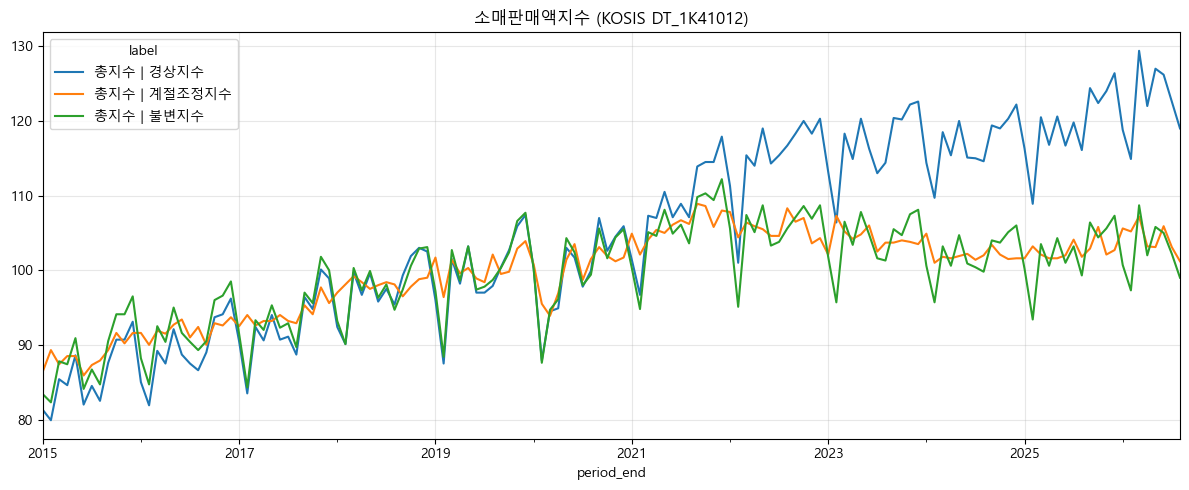

In [9]:
import matplotlib
import matplotlib.pyplot as plt
import platform
from matplotlib import font_manager

for name in ({"Windows": ["Malgun Gothic"], "Darwin": ["AppleGothic"]}.get(platform.system(), []) + ["NanumGothic"]):
    if name in {f.name for f in font_manager.fontManager.ttflist}:
        matplotlib.rcParams["font.family"] = name
        break
matplotlib.rcParams["axes.unicode_minus"] = False

if SAVE_DB:
    rs = load_kosis_long(alias="retail_sales_index", start="2015-01-01")
    if rs.empty:
        print("소매판매액지수 데이터가 없습니다.")
    else:
        wide = rs.pivot_table(index="period_end", columns="label", values="value", aggfunc="last")
        print("시리즈 수:", wide.shape[1], "| 기간:", wide.index.min().date(), "~", wide.index.max().date())
        print("\n시리즈 이름 예시:")
        for c in list(wide.columns)[:10]:
            print("  ", c)
        # 첫 분류(보통 '총지수') 계열만 그림
        cols = [c for c in wide.columns if "총지수" in c][:4] or list(wide.columns[:4])
        ax = wide[cols].plot(figsize=(12, 5), title="소매판매액지수 (KOSIS DT_1K41012)")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

## 9. 수집된 KOSIS 데이터를 DataFrame으로 보기
DB(investar)에 저장된 KOSIS 데이터를 불러옵니다. 1~4번 셀만 실행했어도 볼 수 있습니다 (수집 없이 조회만).

- `kosis_long` : 긴 표. 한 행 = 시리즈 하나의 한 시점 (통계표, 항목, 분류, 단위, 기간, 값)
- `kosis_wide[alias]` : 넓은 표. 행 = 기간, 열 = 시리즈 (통계표별로 따로)
- `kosis_view(alias, 키워드)` : 원하는 시리즈만 골라 넓은 표로 보기

In [10]:
pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 60)

# ── 긴 표: 수집된 전체 KOSIS 데이터
_t = time.perf_counter()
_raw = load_kosis_long()
print(f"DB에서 불러오기 {time.perf_counter() - _t:.1f}초")
kosis_long = (_raw.rename(columns={
                  "table_alias": "alias", "tbl_name": "통계표", "itm_name": "항목",
                  "dims_label": "분류", "unit": "단위", "period_end": "기간", "value": "값"})
              [["alias", "통계표", "분류", "항목", "단위", "기간", "값", "series_id", "label"]]
              .sort_values(["alias", "분류", "항목", "기간"])
              .reset_index(drop=True))

# 통계표별 요약
kosis_summary = (kosis_long.groupby(["alias", "통계표"])
                 .agg(시리즈수=("series_id", "nunique"), 행수=("값", "size"),
                      시작=("기간", "min"), 마지막=("기간", "max"))
                 .reset_index())
print("수집된 KOSIS 데이터:", f"{len(kosis_long):,}행")
kosis_summary

DB에서 불러오기 0.6초
수집된 KOSIS 데이터: 43,252행


,alias,통계표,시리즈수,행수,시작,마지막
0,kosis_376_sdmp042v,[자본시장] 19. 주식 신용거래,22,1716,2010-01-31,2016-06-30
1,online_shopping_by_channel,온라인쇼핑몰 판매매체별/상품군별거래액,78,8832,2017-01-31,2026-08-31
2,online_shopping_by_operation,온라인쇼핑몰 운영형태별/상품군별거래액,78,8832,2017-01-31,2026-08-31
3,online_shopping_by_scope,온라인쇼핑몰 취급상품범위별/상품군별거래액,78,8832,2017-01-31,2026-08-31
4,retail_sales_by_store_type,소매업태별 판매액,8,640,2020-01-31,2026-08-31
5,retail_sales_index,재별 및 상품군별 소매판매액지수(2020＝100.0),72,14400,2010-01-31,2026-08-31


In [11]:
# ── 넓은 표: 통계표(alias)별로 행 = 기간, 열 = '분류 | 항목'
kosis_wide = {
    a: g.pivot_table(index="기간", columns="label", values="값", aggfunc="last").sort_index()
    for a, g in kosis_long.groupby("alias")
}
for a, w in kosis_wide.items():
    print(f"[{a}] {w.shape[0]}개 기간 x {w.shape[1]}개 시리즈  ({w.index.min().date()} ~ {w.index.max().date()})")

# 예: 소매판매액지수 최근 12개월
kosis_wide.get("retail_sales_index", pd.DataFrame()).tail(12)

[kosis_376_sdmp042v] 78개 기간 x 22개 시리즈  (2010-01-31 ~ 2016-06-30)
[online_shopping_by_channel] 116개 기간 x 78개 시리즈  (2017-01-31 ~ 2026-08-31)
[online_shopping_by_operation] 116개 기간 x 78개 시리즈  (2017-01-31 ~ 2026-08-31)
[online_shopping_by_scope] 116개 기간 x 78개 시리즈  (2017-01-31 ~ 2026-08-31)
[retail_sales_by_store_type] 80개 기간 x 8개 시리즈  (2020-01-31 ~ 2026-08-31)
[retail_sales_index] 200개 기간 x 72개 시리즈  (2010-01-31 ~ 2026-08-31)


label,가구 | 경상지수,가구 | 계절조정지수,가구 | 불변지수,가방 | 경상지수,가방 | 불변지수,가전제품 | 경상지수,가전제품 | 계절조정지수,가전제품 | 불변지수,국내 승용차 | 경상지수,국내 승용차 | 불변지수,기타내구재 | 경상지수,기타내구재 | 계절조정지수,기타내구재 | 불변지수,기타비내구재 | 경상지수,기타비내구재 | 계절조정지수,기타비내구재 | 불변지수,기타준내구재 | 경상지수,기타준내구재 | 계절조정지수,기타준내구재 | 불변지수,내구재 | 경상지수,내구재 | 계절조정지수,내구재 | 불변지수,비내구재 | 경상지수,비내구재 | 계절조정지수,비내구재 | 불변지수,...,의약품 | 경상지수,의약품 | 계절조정지수,의약품 | 불변지수,준내구재 | 경상지수,준내구재 | 계절조정지수,준내구재 | 불변지수,차량연료 | 경상지수,차량연료 | 계절조정지수,차량연료 | 불변지수,총지수 | 경상지수,총지수 | 계절조정지수,총지수 | 불변지수,컴퓨터 | 경상지수,컴퓨터 | 불변지수,통신기기 | 경상지수,통신기기 | 불변지수,통신기기 및 컴퓨터 | 경상지수,통신기기 및 컴퓨터 | 계절조정지수,통신기기 및 컴퓨터 | 불변지수,합계(승용차 제외) | 경상지수,합계(승용차 제외) | 계절조정지수,합계(승용차 제외) | 불변지수,화장품 | 경상지수,화장품 | 계절조정지수,화장품 | 불변지수
기간,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-09-30,97.7,77.2,74.2,167.8,150.6,77.7,80.9,77.1,120.6,110.7,141.0,127.1,127.7,146.1,131.0,130.1,107.9,91.3,91.1,117.7,106.5,110.2,129.5,99.0,105.3,...,152.2,141.0,144.6,119.3,109.5,104.1,133.8,99.9,100.3,124.4,102.9,106.4,110.2,106.3,125.4,125.9,121.0,119.5,120.1,123.0,101.6,104.2,105.7,82.1,87.6
2025-10-31,98.3,74.0,75.7,176.4,158.4,74.6,79.3,74.0,100.5,92.2,137.3,127.3,124.9,150.1,133.2,132.7,109.8,89.5,92.5,101.9,101.9,94.8,125.1,105.9,101.6,...,151.1,146.8,143.5,145.4,110.8,126.4,132.6,99.2,99.3,122.4,105.8,104.4,93.3,89.6,102.7,101.6,100.0,103.1,98.1,124.2,105.3,105.1,98.0,81.4,81.0
2025-11-30,102.6,76.5,78.4,177.9,161.6,81.8,78.8,82.0,114.6,105.4,139.2,126.1,125.2,151.9,134.0,132.8,108.5,87.9,91.1,111.3,101.1,103.7,123.2,100.3,100.0,...,153.1,144.5,145.4,145.6,108.6,125.9,143.1,99.6,103.3,124.0,102.1,105.6,119.2,113.6,97.7,96.7,104.4,99.8,102.0,123.9,101.1,104.7,103.8,84.4,85.8
2025-12-31,106.7,77.2,80.7,197.0,175.1,77.0,80.5,76.9,111.8,102.7,152.3,124.3,136.2,160.0,134.7,137.8,112.9,89.1,94.8,112.6,100.3,105.1,128.4,101.1,103.4,...,157.3,144.0,149.6,141.4,110.7,122.1,146.1,99.3,103.5,126.4,102.7,107.3,119.6,113.2,89.0,88.1,98.4,92.9,95.9,126.2,101.7,105.9,110.3,87.8,91.1
2026-01-31,106.7,79.7,80.7,183.5,159.0,77.0,81.0,76.5,95.7,87.9,151.0,144.6,135.2,152.8,132.4,130.8,103.6,91.9,86.8,103.9,105.3,96.9,125.5,101.7,101.1,...,155.0,144.6,147.3,121.3,117.5,104.4,136.2,102.2,99.2,118.8,105.6,100.7,132.8,124.3,96.9,95.8,107.8,100.4,104.7,120.8,104.7,101.3,104.7,93.4,86.4
2026-02-28,100.6,77.2,76.1,172.0,149.0,71.6,82.3,71.2,98.9,91.3,138.4,133.6,123.8,142.2,134.4,123.1,94.8,89.8,79.8,100.4,103.6,93.3,123.4,104.0,99.6,...,147.4,148.4,140.2,111.4,111.0,95.6,120.7,100.5,88.6,114.9,105.2,97.3,117.7,105.9,83.9,83.0,94.2,86.4,90.2,115.7,103.8,97.0,98.1,87.2,80.8
2026-03-31,109.9,78.0,83.1,189.1,168.0,89.3,94.0,88.5,134.1,122.9,160.5,140.4,143.0,164.9,140.0,143.3,113.9,93.4,94.6,128.9,114.2,119.2,128.0,102.6,101.9,...,154.2,148.0,147.0,134.3,111.4,115.2,151.9,101.2,100.8,129.4,107.2,108.7,125.9,111.4,133.8,131.3,131.6,121.0,125.5,127.6,105.6,106.1,116.6,91.1,95.7
2026-04-30,96.6,74.5,72.1,183.8,161.2,77.9,82.0,77.1,114.7,105.1,150.8,136.3,133.6,153.5,135.2,136.0,108.1,88.8,89.5,109.9,101.6,101.4,124.3,101.4,98.5,...,160.9,152.0,152.8,133.1,110.7,113.9,147.7,92.8,90.7,122.0,103.2,102.0,100.6,84.5,85.4,83.8,90.1,85.7,84.2,121.3,102.1,100.3,109.7,89.9,90.5
2026-05-31,103.7,78.7,77.4,197.6,173.3,90.1,83.2,88.3,95.7,88.1,153.6,131.3,135.8,155.5,131.7,135.9,112.2,91.0,92.3,107.8,97.4,99.3,131.1,102.2,103.4,...,156.1,148.9,148.4,143.9,113.7,122.2,159.9,97.1,96.8,127.0,103.1,105.8,101.4,85.1,89.7,88.0,93.3,89.5,87.3,128.9,103.4,106.1,119.4,95.9,98.3


In [12]:
def kosis_view(alias, keyword=None, start=None, last_n=None):
    """원하는 시리즈만 넓은 표로. keyword 는 '총지수', '계절조정' 처럼 분류/항목 이름 일부 (여러 개면 리스트).
    ※ 이 함수는 수집하지 않고, 위에서 만든 kosis_wide(메모리)에서 골라 보여주기만 함 (즉시 실행)"""
    w = kosis_wide.get(alias)
    if w is None:
        print("없는 alias 입니다. 사용 가능:", list(kosis_wide))
        return pd.DataFrame()
    if keyword:
        kws = [keyword] if isinstance(keyword, str) else list(keyword)
        w = w[[c for c in w.columns if all(k in c for k in kws)]]
    if start:
        w = w[w.index >= pd.Timestamp(start)]
    return w.tail(last_n) if last_n else w


# 사용 예
#   kosis_view("retail_sales_index", "총지수")                  # 총지수 계열만
#   kosis_view("retail_sales_index", ["총지수", "계절조정"])     # 두 단어가 모두 들어간 계열
#   kosis_view("retail_sales_index", start="2020-01-01")        # 2020년 이후
#   kosis_view("online_shopping_by_channel", "모바일", last_n=12)   # 모바일 쇼핑 거래액
#   kosis_view("retail_sales_by_store_type", last_n=12)          # 업태별 판매액
#   kosis_long[kosis_long["alias"] == "retail_sales_index"]     # 긴 표로 보기
kosis_view("retail_sales_index", "총지수", last_n=12)

label,총지수 | 경상지수,총지수 | 계절조정지수,총지수 | 불변지수
기간,,,
2025-09-30,124.4,102.9,106.4
2025-10-31,122.4,105.8,104.4
2025-11-30,124.0,102.1,105.6
2025-12-31,126.4,102.7,107.3
2026-01-31,118.8,105.6,100.7
2026-02-28,114.9,105.2,97.3
2026-03-31,129.4,107.2,108.7
2026-04-30,122.0,103.2,102.0
2026-05-31,127.0,103.1,105.8
